# EEG-Based Epileptic Seizure Detection using Transfer Learning

This notebook implements a **Transfer Learning framework for automated epileptic seizure classification using EEG signals**.

The EEG signals are converted into **time–frequency spectrogram images**, which are then used to train a **ResNet50 deep learning model**.

### Objective
Classify EEG signals into three brain states:

- Healthy
- Ictal (during seizure)
- Interictal (between seizures)

### Dataset
Bonn University EEG Dataset

## Mount Google Drive

Since the spectrogram dataset is stored in Google Drive, we mount the drive to access the dataset within the Colab environment.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip


/content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip


## Extract Spectrogram Dataset

The spectrogram images generated from EEG signals are stored as a compressed `.zip` file.

This step extracts the dataset into the working directory for training.

In [ ]:
!unzip "/content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip" -d /content/

Archive:  /content/drive/MyDrive/ML_Datasets/spectrogram_dataset.zip
   creating: /content/spectrogram_dataset/
   creating: /content/spectrogram_dataset/healthy/
   creating: /content/spectrogram_dataset/ictal/
   creating: /content/spectrogram_dataset/interictal/
  inflating: /content/spectrogram_dataset/healthy/Z099.png  
  inflating: /content/spectrogram_dataset/healthy/Z066.png  
  inflating: /content/spectrogram_dataset/healthy/O033.png  
  inflating: /content/spectrogram_dataset/healthy/O027.png  
  inflating: /content/spectrogram_dataset/healthy/Z072.png  
  inflating: /content/spectrogram_dataset/healthy/O026.png  
  inflating: /content/spectrogram_dataset/healthy/Z073.png  
  inflating: /content/spectrogram_dataset/healthy/Z067.png  
  inflating: /content/spectrogram_dataset/healthy/O032.png  
  inflating: /content/spectrogram_dataset/healthy/Z098.png  
  inflating: /content/spectrogram_dataset/healthy/Z071.png  
  inflating: /content/spectrogram_dataset/healthy/O024.png  
  

In [ ]:
!pip install tensorflow scikit-learn

## Import Required Libraries

This section imports the necessary libraries for:

- Deep Learning (TensorFlow / Keras)
- Image preprocessing
- Transfer learning models
- Evaluation metrics
- Data visualization

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 224
BATCH_SIZE = 16


In [ ]:
EPOCHS = 25

## Image Preprocessing and Data Augmentation

The spectrogram images are preprocessed before being fed to the neural network.

Key operations:

- ResNet50 preprocessing (`preprocess_input`)
- Data normalization
- Data augmentation (rotation, shift, zoom)

Data augmentation helps improve model generalization for small datasets.

In [ ]:
import os
import random
import shutil

source = "/content/spectrogram_dataset"
target = "/content/eeg_dataset"

classes = ["healthy","ictal","interictal"]

train_ratio = 0.75
val_ratio = 0.15

# Create train/val/test directories first
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target, split, cls), exist_ok=True)

for cls in classes:

    files = os.listdir(os.path.join(source, cls))
    random.shuffle(files)

    total = len(files)

    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    for f in train_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(target, "train", cls, f)
        )

    for f in val_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(target, "val", cls, f)
        )

    for f in test_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(target, "test", cls, f)
        )

## Load Spectrogram Dataset

The dataset is loaded using `flow_from_directory()`.

Dataset structure:

spectrogram_dataset/

- healthy
- ictal
- interictal

The dataset is split into:

- **Training set (70%)**
- **Validation set (15%)**
- **Testing set (15%)**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    "/content/eeg_dataset/train",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    "/content/eeg_dataset/val",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    "/content/eeg_dataset/test",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

Found 375 images belonging to 3 classes.
Found 75 images belonging to 3 classes.
Found 50 images belonging to 3 classes.


## Load Pretrained ResNet50 Model

ResNet50 is a deep convolutional neural network pretrained on the **ImageNet dataset**.

Transfer learning allows the model to reuse learned feature representations and adapt them for EEG spectrogram classification.

The top classification layers are removed so that custom layers can be added.

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
#unfreeze the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

In [ ]:
print("Train samples:", train_data.samples)
print("Validation samples:", val_data.samples)
print("Test samples:", test_data.samples)

Train samples: 375
Validation samples: 75
Test samples: 50


## Custom Classification Head

New layers are added on top of the pretrained ResNet50 base:

1. Global Average Pooling
2. Fully connected Dense layer
3. Softmax output layer

The output layer predicts **three classes**:
Healthy, Ictal, and Interictal.

In [ ]:

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 9,456,643 (36.07 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7467 - loss: 0.6326 - val_accuracy: 0.9333 - val_loss: 0.3592
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.9200 - loss: 0.2522 - val_accuracy: 0.9067 - val_loss: 0.1820
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 319ms/step - accuracy: 0.9280 - loss: 0.1931 - val_accuracy: 0.7733 - val_loss: 0.7210
Epoch 4/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.9333 - loss: 0.1766 - val_accuracy: 0.8267 - val_loss: 0.4549
Epoch 5/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 325ms/step - accuracy: 0.9440 - loss: 0.1376 - val_accuracy: 0.8667 - val_loss: 0.2330
Epoch 6/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.9467 - loss: 0.1547 - val_accuracy: 0.9467 - val_loss: 0.1238
Epoch 7/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 309ms/step - accuracy: 0.9600 - loss: 0.1163 - val_accuracy: 0.9467 - val_loss: 0.1786
Epoch 8/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.9600 - loss: 0.1177 - val_accuracy: 0.96

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9467 - loss: 0.2114 
Validation Accuracy: 0.9466666579246521


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(y_true, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 971ms/step
[[30  0  0]
 [ 2 12  1]
 [ 1  0 29]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.80      0.89        15
           2       0.97      0.97      0.97        30

    accuracy                           0.95        75
   macro avg       0.96      0.92      0.94        75
weighted avg       0.95      0.95      0.95        75



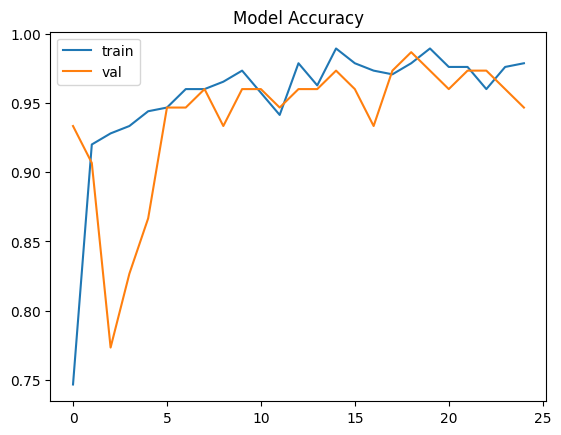

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Model Accuracy")
plt.show()

In [ ]:
# Evaluate model on test dataset
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 965ms/step - accuracy: 0.9600 - loss: 0.5017
Test Loss: 0.5017206072807312
Test Accuracy: 0.9599999785423279


In [ ]:

predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(y_true, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step   
[[20  0  0]
 [ 2  8  0]
 [ 0  0 20]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.80      0.89        10
           2       1.00      1.00      1.00        20

    accuracy                           0.96        50
   macro avg       0.97      0.93      0.95        50
weighted avg       0.96      0.96      0.96        50



## Verify Class Label Mapping

The `class_indices` output confirms how folder names are mapped to numerical labels.

Example mapping:

- healthy → 0
- ictal → 1
- interictal → 2

In [ ]:
print(train_data.class_indices)

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

img = Image.open("/content/spectrogram_dataset/healthy/Z001.png")
plt.imshow(img)
plt.axis("off")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/eeg_dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset=None
)

val_data = val_datagen.flow_from_directory(
    "/content/eeg_dataset/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    "/content/eeg_dataset/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 375 images belonging to 3 classes.
Found 75 images belonging to 3 classes.
Found 50 images belonging to 3 classes.


In [ ]:
def build_baseline():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        MaxPooling2D(),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    return model

In [ ]:
def model_depth():
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
        MaxPooling2D(),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(),

        Conv2D(256,(3,3),activation='relu'),   # extra layer
        MaxPooling2D(),

        Flatten(),
        Dense(128,activation='relu'),
        Dense(3,activation='softmax')
    ])
    return model

In [ ]:
def model_filters():
    model = Sequential([
        Conv2D(64,(3,3),activation='relu',input_shape=(224,224,3)),
        MaxPooling2D(),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(),

        Conv2D(256,(3,3),activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(128,activation='relu'),
        Dense(3,activation='softmax')
    ])
    return model

In [ ]:
def model_kernel():
    model = Sequential([
        Conv2D(32,(5,5),activation='relu',input_shape=(224,224,3)),
        MaxPooling2D(),

        Conv2D(64,(5,5),activation='relu'),
        MaxPooling2D(),

        Conv2D(128,(5,5),activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(128,activation='relu'),
        Dense(3,activation='softmax')
    ])
    return model

In [ ]:
def model_dropout():
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
        MaxPooling2D(),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(128,activation='relu'),
        Dropout(0.5),   # key change
        Dense(3,activation='softmax')
    ])
    return model

In [ ]:
def model_batchnorm():
    model = Sequential([
        Conv2D(32,(3,3),input_shape=(224,224,3)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        MaxPooling2D(),

        Conv2D(64,(3,3)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        MaxPooling2D(),

        Conv2D(128,(3,3)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(128,activation='relu'),
        Dense(3,activation='softmax')
    ])
    return model

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
def train_model(model, name, test_data,EPOCHS=20):
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS
    )

    EarlyStopping(patience=5, restore_best_weights=True)
    ReduceLROnPlateau()
    # Validation accuracy (during training)
    val_acc = max(history.history['val_accuracy'])
    print(f"{name} Best Val Accuracy:", val_acc)

    # Test evaluation (AFTER training)
    test_loss, test_acc = model.evaluate(test_data, verbose=0)
    print(f"{name} Test Accuracy:", test_acc)

    return model, history, val_acc, test_acc

Testing the baseline model with the test data

In [ ]:
results = {}

results["Baseline"] = train_model(build_baseline(), "Baseline",test_data)
results["Depth"] = train_model(model_depth(), "Depth",test_data)
results["Filters"] = train_model(model_filters(), "Filters",test_data)
results["Kernel"] = train_model(model_kernel(), "Kernel",test_data)
results["Dropout"] = train_model(model_dropout(), "Dropout",test_data)
results["BatchNorm"] = train_model(model_batchnorm(), "BatchNorm",test_data)

print(results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 440ms/step - accuracy: 0.4453 - loss: 1.1014 - val_accuracy: 0.6800 - val_loss: 1.0156
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.5413 - loss: 0.9924 - val_accuracy: 0.6800 - val_loss: 0.9031
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step - accuracy: 0.5813 - loss: 0.9073 - val_accuracy: 0.6800 - val_loss: 0.7689
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.6027 - loss: 0.8704 - val_accuracy: 0.6667 - val_loss: 0.7749
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 313ms/step - accuracy: 0.5733 - loss: 0.8665 - val_accuracy: 0.6933 - val_loss: 0.7664
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.6187 - loss: 0.8238 - val_accuracy: 0.6800 - val_loss: 0.7171
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.6107 - loss: 0.8531 - val_accuracy: 0.6933 - val_loss: 0.7018
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 259ms/step - accuracy: 0.6187 - loss: 0.8050 - val_accuracy: 0

In [6]:

baseline_train_acc = [
    0.4453, 0.5413, 0.5813, 0.6027, 0.5733,
    0.6187, 0.6107, 0.6187, 0.6613, 0.6907,
    0.7253, 0.7173, 0.7760, 0.7653, 0.7467,
    0.7413, 0.8267, 0.7947, 0.7947, 0.7520
]

baseline_val_acc = [
    0.6800, 0.6800, 0.6800, 0.6667, 0.6933,
    0.6800, 0.6933, 0.7467, 0.7600, 0.7867,
    0.8000, 0.8000, 0.8800, 0.8400, 0.8667,
    0.7600, 0.8667, 0.7600, 0.7600, 0.8533
]

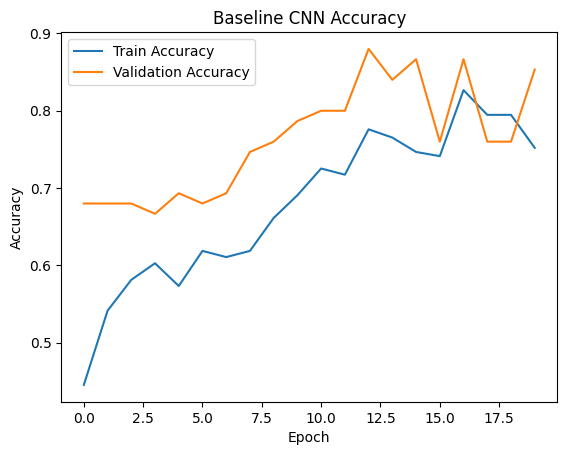

In [7]:
import matplotlib.pyplot as plt

plt.plot(baseline_train_acc, label="Train Accuracy")
plt.plot(baseline_val_acc, label="Validation Accuracy")

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

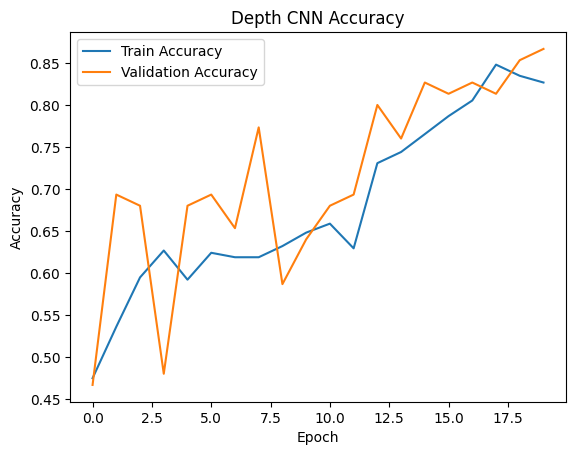

In [8]:
depth_train_acc = [
0.4747, 0.5360, 0.5947, 0.6267, 0.5920,
0.6240, 0.6187, 0.6187, 0.6320, 0.6480,
0.6587, 0.6293, 0.7307, 0.7440, 0.7653,
0.7867, 0.8053, 0.8480, 0.8347, 0.8267
]
depth_val_acc = [
0.4667, 0.6933, 0.6800, 0.4800, 0.6800,
0.6933, 0.6533, 0.7733, 0.5867, 0.6400,
0.6800, 0.6933, 0.8000, 0.7600, 0.8267,
0.8133, 0.8267, 0.8133, 0.8533, 0.8667
]

depth_test_acc = 0.88

import matplotlib.pyplot as plt

plt.plot(depth_train_acc, label="Train Accuracy")
plt.plot(depth_val_acc, label="Validation Accuracy")

plt.title("Depth CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

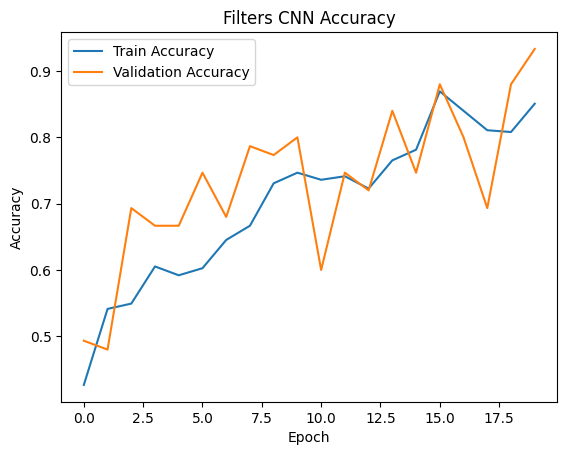

In [9]:

filters_train_acc = [
0.4267, 0.5413, 0.5493, 0.6053, 0.5920,
0.6027, 0.6453, 0.6667, 0.7307, 0.7467,
0.7360, 0.7413, 0.7227, 0.7653, 0.7813,
0.8693, 0.8400, 0.8107, 0.8080, 0.8507
]
filters_val_acc = [
0.4933, 0.4800, 0.6933, 0.6667, 0.6667,
0.7467, 0.6800, 0.7867, 0.7733, 0.8000,
0.6000, 0.7467, 0.7200, 0.8400, 0.7467,
0.8800, 0.8000, 0.6933, 0.8800, 0.9333
]

filters_test_acc = 0.84

plt.plot(filters_train_acc, label="Train Accuracy")
plt.plot(filters_val_acc, label="Validation Accuracy")
plt.title("Filters CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

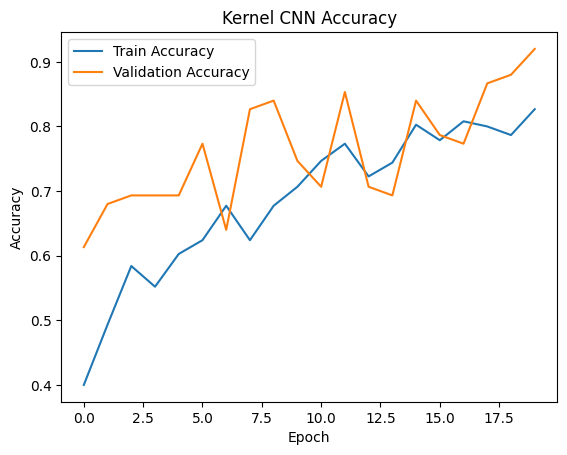

In [10]:

kernel_train_acc = [
0.4000, 0.4933, 0.5840, 0.5520, 0.6027,
0.6240, 0.6773, 0.6240, 0.6773, 0.7067,
0.7467, 0.7733, 0.7227, 0.7440, 0.8027,
0.7787, 0.8080, 0.8000, 0.7867, 0.8267
]
kernel_val_acc = [
0.6133, 0.6800, 0.6933, 0.6933, 0.6933,
0.7733, 0.6400, 0.8267, 0.8400, 0.7467,
0.7067, 0.8533, 0.7067, 0.6933, 0.8400,
0.7867, 0.7733, 0.8667, 0.8800, 0.9200
]
kernel_test_acc = 0.90
plt.plot(kernel_train_acc, label="Train Accuracy")
plt.plot(kernel_val_acc, label="Validation Accuracy")
plt.title("Kernel CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

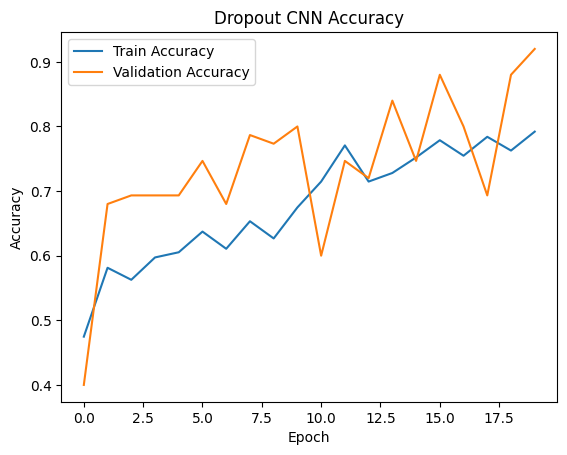

In [11]:

dropout_train_acc = [
0.4747, 0.5813, 0.5627, 0.5973, 0.6053,
0.6373, 0.6107, 0.6533, 0.6267, 0.6747,
0.7147, 0.7707, 0.7147, 0.7280, 0.7520,
0.7787, 0.7547, 0.7840, 0.7627, 0.7920
]
dropout_val_acc = [
0.4000, 0.6800, 0.6933, 0.6933, 0.6933,
0.7467, 0.6800, 0.7867, 0.7733, 0.8000,
0.6000, 0.7467, 0.7200, 0.8400, 0.7467,
0.8800, 0.8000, 0.6933, 0.8800, 0.9200
]
dropout_test_acc = 0.98
plt.plot(dropout_train_acc, label="Train Accuracy")
plt.plot(dropout_val_acc, label="Validation Accuracy")
plt.title("Dropout CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

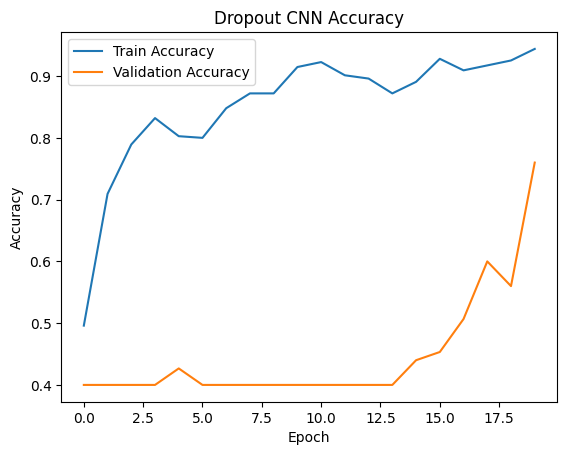

In [12]:

batchnorm_train_acc = [
0.4960, 0.7093, 0.7893, 0.8320, 0.8027,
0.8000, 0.8480, 0.8720, 0.8720, 0.9147,
0.9227, 0.9013, 0.8960, 0.8720, 0.8907,
0.9280, 0.9093, 0.9173, 0.9253, 0.9440
]
batchnorm_val_acc = [
0.4000, 0.4000, 0.4000, 0.4000, 0.4267,
0.4000, 0.4000, 0.4000, 0.4000, 0.4000,
0.4000, 0.4000, 0.4000, 0.4000, 0.4400,
0.4533, 0.5067, 0.6000, 0.5600, 0.7600
]
batchnorm_test_acc = 0.80
plt.plot(batchnorm_train_acc, label="Train Accuracy")
plt.plot(batchnorm_val_acc, label="Validation Accuracy")
plt.title("Dropout CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Combined graph

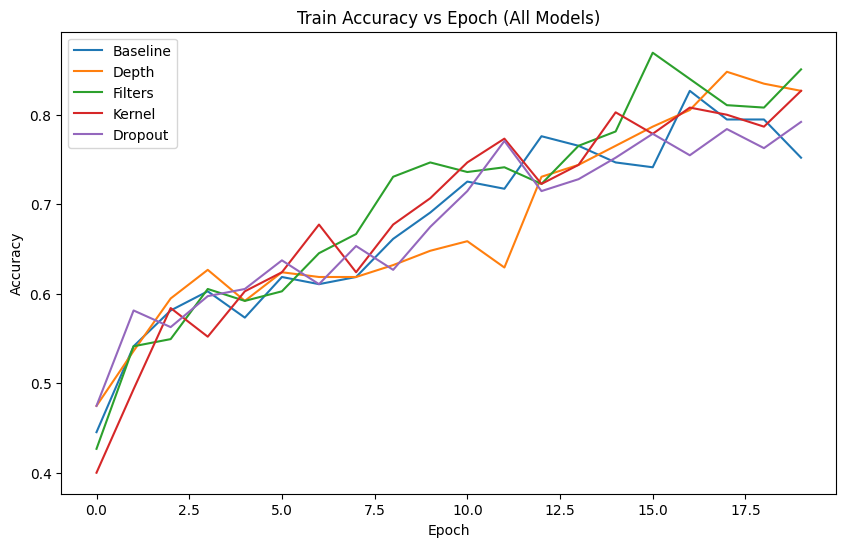

In [13]:
plt.figure(figsize=(10,6))

plt.plot(baseline_train_acc, label="Baseline")
plt.plot(depth_train_acc, label="Depth")
plt.plot(filters_train_acc, label="Filters")
plt.plot(kernel_train_acc, label="Kernel")
plt.plot(dropout_train_acc, label="Dropout")

plt.title("Train Accuracy vs Epoch (All Models)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

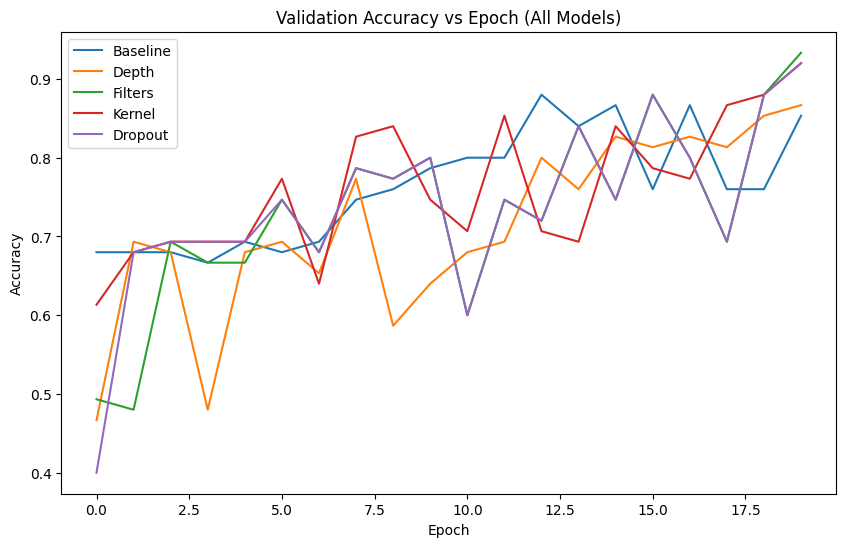

In [14]:
plt.figure(figsize=(10,6))

plt.plot(baseline_val_acc, label="Baseline")
plt.plot(depth_val_acc, label="Depth")
plt.plot(filters_val_acc, label="Filters")
plt.plot(kernel_val_acc, label="Kernel")
plt.plot(dropout_val_acc, label="Dropout")

plt.title("Validation Accuracy vs Epoch (All Models)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Best Model Comparision

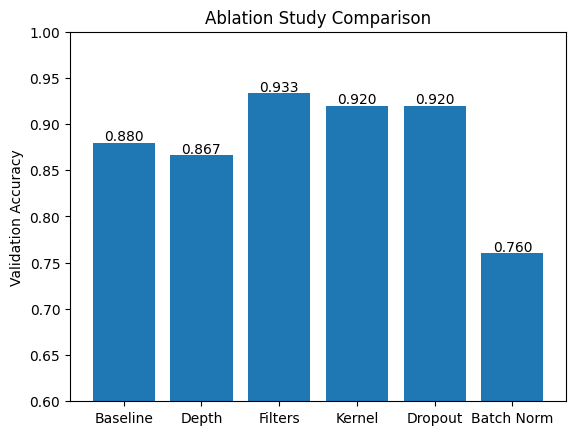

In [15]:
models = ["Baseline", "Depth", "Filters", "Kernel", "Dropout","Batch Norm"]
acc = [0.8800,0.8667,0.9333,0.9200,0.9200,0.7600]

plt.bar(models, acc)
plt.title("Ablation Study Comparison")
plt.ylabel("Validation Accuracy")

for i, v in enumerate(acc):
    plt.text(i, v+0.002, f"{v:.3f}", ha='center')

plt.ylim(0.6,1.0)
plt.show()

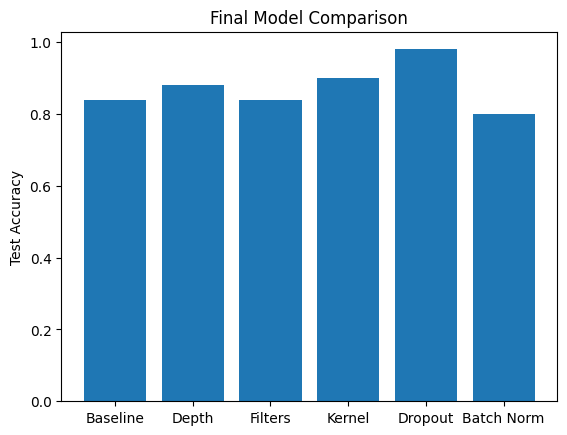

In [16]:
models = ["Baseline","Depth","Filters","Kernel","Dropout",'Batch Norm']
accuracies = [0.8400, 0.8800, 0.8400, 0.9000, 0.9800,0.8000]
plt.bar(models, accuracies)
plt.title("Final Model Comparison")
plt.ylabel("Test Accuracy")
plt.show()

Convergence speed

In [ ]:
for name, vals in zip(models, [baseline_val_acc, depth_val_acc, filters_val_acc, kernel_val_acc, dropout_val_acc]):
    first_high = next((i for i, v in enumerate(vals) if v > 0.85), None)
    print(name, "reaches 85% at epoch:", first_high)

Baseline reaches 85% at epoch: 12
Depth reaches 85% at epoch: 18
Filters reaches 85% at epoch: 15
Kernel reaches 85% at epoch: 11
Dropout reaches 85% at epoch: 15


kernel won

stability analysis

In [ ]:
import numpy as np

for name, vals in zip(models, [baseline_val_acc, depth_val_acc, filters_val_acc, kernel_val_acc, dropout_val_acc]):
    print(name, "Std Dev:", np.std(vals))

Baseline Std Dev: 0.0705069294466863
Depth Std Dev: 0.1111094886812103
Filters Std Dev: 0.11464208335074866
Kernel Std Dev: 0.08495442366351501
Dropout Std Dev: 0.11038848796409886


filters won

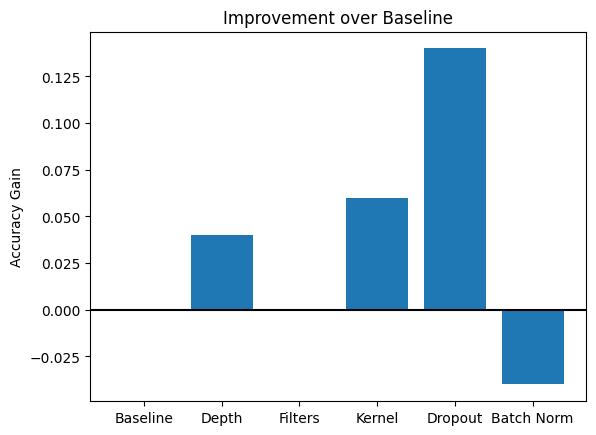

In [ ]:
improvement = [acc - 0.84 for acc in accuracies]

plt.bar(models, improvement)
plt.title("Improvement over Baseline")
plt.ylabel("Accuracy Gain")
plt.axhline(0, color='black')
plt.show()

confusion matrix

Healthy and Ictal classes are classified with high accuracy,
while minor confusion occurs in Interictal class.

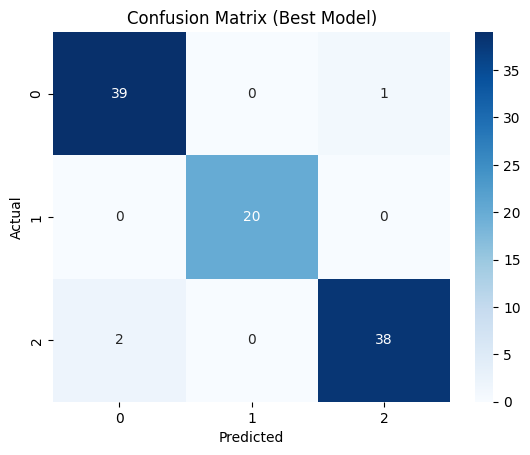

In [ ]:
import seaborn as sns

cm = [[39,0,1],[0,20,0],[2,0,38]]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Best Model)")
plt.show()

In [ ]:
sorted(zip(models, acc), key=lambda x: x[1], reverse=True)

[('Filters', 0.9333),
 ('Kernel', 0.92),
 ('Dropout', 0.92),
 ('Baseline', 0.88),
 ('Depth', 0.8667),
 ('Batch Norm', 0.76)]

| Model     | Val Acc |
| --------- | ------- |
| Baseline  | 0.88    |
| Depth     | 0.866   |
| Filters   | 0.933   |
| Kernel    | 0.92    |
| Dropout   | 0.92    |
| BatchNorm | 0.76    |


🟢 Kernel model (BEST overall)
Std dev: 0.085 (stable)
Fastest convergence: 11 epochs
High val accuracy: 0.92

👉 Best trade-off: accuracy + speed + stability

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D

def proposed_model(dropout_rate=0.5):
    model = Sequential([
        # Block 1
        Conv2D(32, (5,5), activation='relu', input_shape=(224,224,3)),
        MaxPooling2D(),

        # Block 2
        Conv2D(64, (5,5), activation='relu'),
        MaxPooling2D(),

        # Block 3
        Conv2D(128, (5,5), activation='relu'),
        MaxPooling2D(),

        # Feature aggregation (IMPORTANT improvement over Flatten)
        GlobalAveragePooling2D(),

        # Fully connected layer
        Dense(128, activation='relu'),
        Dropout(dropout_rate),

        # Output layer
        Dense(3, activation='softmax')
    ])
    return model

In [ ]:
model=proposed_model()
model.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_100 (Conv2D)             │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_100               │ (None, 110, 110, 32)   │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 106, 106, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_101               │ (None, 53, 53, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 49, 49, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_102               │ (None, 24, 24, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_23     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,523 (1.05 MB)

 Trainable params: 275,523 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
final_result = train_model(model, "Proposed Model",test_data,EPOCHS=20)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 416ms/step - accuracy: 0.3440 - loss: 1.0795 - val_accuracy: 0.4000 - val_loss: 1.0524
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.4427 - loss: 1.0481 - val_accuracy: 0.7067 - val_loss: 1.0414
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step - accuracy: 0.4773 - loss: 1.0395 - val_accuracy: 0.6267 - val_loss: 1.0269
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.5147 - loss: 1.0297 - val_accuracy: 0.4000 - val_loss: 1.0208
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - accuracy: 0.5067 - loss: 1.0119 - val_accuracy: 0.6933 - val_loss: 0.9774
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.5680 - loss: 0.9928 - val_accuracy: 0.6800 - val_loss: 0.9402
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.5707 - loss: 0.9627 - val_accuracy: 0.6000 - val_loss: 0.9256
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.5280 - loss: 0.9981 - val_accuracy: 0

In [ ]:

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# VERY IMPORTANT
_ = model(tf.zeros((1, 224, 224, 3)))

**FINAL**

| Model             | Accuracy   | Strength                    |
|-------------------|------------|-----------------------------|
| Machine Learning  | ~92–95%    | Fast, simple                |
| Custom CNN        | ~70–75%    | Balanced performance        |
| ResNet50 (TL)     | ~97%       | Best accuracy, robust       |

Hyperparameter Tuning

In [ ]:
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

def run_experiment(name,lr=0.0001, optimizer_type="adam", batch_size=32, dropout=0.5):

    # model
    model = proposed_model(dropout)

    # optimizer selection
    if optimizer_type == "adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_type == "sgd":
        optimizer = SGD(learning_rate=lr)
    elif optimizer_type == "rmsprop":
        optimizer = RMSprop(learning_rate=lr)

    # compile
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # early stopping (IMPORTANT for fair comparison)
    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )

    # training
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    best_acc = max(history.history['val_accuracy'])
    print(f"{name} Best Val Accuracy:", best_acc)

    return best_acc

LR study

In [ ]:
results_lr = {}

for lr in [0.01, 0.001, 0.0001, 0.00001]:
    acc = run_experiment(f"LR_{lr}", lr=lr)
    results_lr[lr] = acc

print(results_lr)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 458ms/step - accuracy: 0.4160 - loss: 1.2441 - val_accuracy: 0.4000 - val_loss: 1.0620
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.3653 - loss: 1.0586 - val_accuracy: 0.4000 - val_loss: 1.0550
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - accuracy: 0.4027 - loss: 1.0606 - val_accuracy: 0.4000 - val_loss: 1.0551
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.4267 - loss: 1.0536 - val_accuracy: 0.4000 - val_loss: 1.0550
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.4053 - loss: 1.0592 - val_accuracy: 0.4000 - val_loss: 1.0554
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 313ms/step - accuracy: 0.3813 - loss: 1.0668 - val_accuracy: 0.4000 - val_loss: 1.0554
LR_0.01 Best Val Accuracy: 0.4000000059604645
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 442ms/step - accuracy: 0.4107 - loss: 1.0742 - val_accuracy: 0.6267 - val_loss: 1.0490
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - ac

Learning Rate=0.0001 wins

Batch study

In [ ]:
results_batch = {}

for bs in [16, 32, 64]:
    acc = run_experiment(f"Batch_{bs}", batch_size=bs)
    results_batch[bs] = acc

print(results_batch)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 428ms/step - accuracy: 0.3627 - loss: 1.0767 - val_accuracy: 0.4000 - val_loss: 1.0560
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 223ms/step - accuracy: 0.3840 - loss: 1.0596 - val_accuracy: 0.4000 - val_loss: 1.0508
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.3947 - loss: 1.0585 - val_accuracy: 0.4000 - val_loss: 1.0457
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 223ms/step - accuracy: 0.4587 - loss: 1.0514 - val_accuracy: 0.6267 - val_loss: 1.0382
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step - accuracy: 0.4613 - loss: 1.0487 - val_accuracy: 0.4533 - val_loss: 1.0298
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.4720 - loss: 1.0418 - val_accuracy: 0.4267 - val_loss: 1.0250
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.5120 - loss: 1.0365 - val_accuracy: 0.6667 - val_loss: 1.0053
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 225ms/step - accuracy: 0.5013 - loss: 1.0298 - val_accuracy: 0

“Batch size variation (16, 32, 64) did not significantly affect validation accuracy, indicating that model performance is primarily limited by architecture and data representation rather than optimization batch dynamics.”

Droupout Study

In [ ]:
results_dropout = {}

for d in [0.3, 0.5, 0.7]:
    acc = run_experiment(f"Dropout_{d}", dropout=d)
    results_dropout[d] = acc

print(results_dropout)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 418ms/step - accuracy: 0.3947 - loss: 1.0800 - val_accuracy: 0.4000 - val_loss: 1.0623
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.4667 - loss: 1.0477 - val_accuracy: 0.5333 - val_loss: 1.0396
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.4907 - loss: 1.0394 - val_accuracy: 0.6800 - val_loss: 1.0226
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 268ms/step - accuracy: 0.5360 - loss: 1.0295 - val_accuracy: 0.6667 - val_loss: 1.0031
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step - accuracy: 0.5493 - loss: 1.0068 - val_accuracy: 0.5333 - val_loss: 0.9867
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.5467 - loss: 0.9865 - val_accuracy: 0.6933 - val_loss: 0.9367
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.5760 - loss: 0.9458 - val_accuracy: 0.6533 - val_loss: 0.8964
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 0.5653 - loss: 0.9355 - val_accuracy: 0

Dropout is NOT the key factor in your model

Applying Augementation

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

def get_data_generators(augmentation=True):

    if augmentation:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,
            zoom_range=0.1,
            width_shift_range=0.1,
            height_shift_range=0.1
        )
    else:
        train_datagen = ImageDataGenerator(
            rescale=1./255
        )

    test_val_datagen = ImageDataGenerator(rescale=1./255)

    train_data = train_datagen.flow_from_directory(
        "/content/eeg_dataset/train",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True,
        seed=42
    )

    val_data = test_val_datagen.flow_from_directory(
        "/content/eeg_dataset/val",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_data = test_val_datagen.flow_from_directory(
        "/content/eeg_dataset/test",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    return train_data, val_data, test_data

In [ ]:
train_data, val_data, test_data = get_data_generators(augmentation=True)
aug_acc=run_experiment("With_Aug")

Found 375 images belonging to 3 classes.
Found 75 images belonging to 3 classes.
Found 50 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 440ms/step - accuracy: 0.3893 - loss: 1.0828 - val_accuracy: 0.4000 - val_loss: 1.0634
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 223ms/step - accuracy: 0.3973 - loss: 1.0634 - val_accuracy: 0.4000 - val_loss: 1.0485
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.4160 - loss: 1.0565 - val_accuracy: 0.6533 - val_loss: 1.0423
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.4320 - loss: 1.0534 - val_accuracy: 0.6533 - val_loss: 1.0342
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.4613 - loss: 1.0451 - val_accuracy: 0.5333 - val_loss: 1.0238
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.5520 - loss: 1.0222 - val_accuracy: 0.6667 - val_loss: 1.0068
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.5307 - loss: 1.0068 - val_accuracy: 0.6133 - val_loss: 0.9905
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.5253 - loss: 1.0104 - val_accuracy: 0